# <font color='orange'>TME ROBOTIQUE ET APPRENTISSAGE</font>
# <font color='orange'>1. Stratégies d'Evolution</font>

# <font color="green">Version ETUDIANT·ES 2025-2026</font>

*mise à jour: 24/2/2026*

Ce notebook doit être exécuté dans [Google Colab](colab.research.google.com/) ou dans Jupyter.

A la fin du TME, vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules doivent être exécutées avec les graphes visibles
* un **bref** commentaire lorsque c'est demandé. Pour toutes les questions, une à deux phrases suffisent

*Le sujet est à faire en binome.*

# COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **ANTIPIN Vladislav 21242244**
* Étudiant 2: **OUNDJIAN Milos 21500050**

---
---
---

# <font color='orange'>PREAMBULE: initialisation</font>

# Importation des librairies nécessaires et fonctions utiles

Il n'est pas nécessaire de regarder le code de ces cellules, elles sont utiles pour les fonctions utilisées dans la partie A.

Remarque: *Sauf en cas de redémarrage du noyau, il suffit d'exécuter ces cellules une seule fois.*

In [3]:
from datetime import datetime
from datetime import date
#import importlib # une seule fois
import sys
import random
import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.optimize import minimize

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-02-26 13:55:56 GMT
OK.


In [4]:
#!pip install numpy scipy matplotlib pandas sympy nose
# !pip install deap
# !pip install cma
#!pip install --user pygame

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-02-26 13:55:56 GMT
OK.


In [796]:
# plot

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import random
from scipy.optimize import minimize


def plot_results(my_func, my_points, min_x=-30, max_x=30, min_y=-30, max_y=30, nbx=100, nby=100, title="Title"):
    """Plots a 2D function with a heatmap and the points given as argument are plotted on top of it

    Plots a 2D function with a heatmap and the points given as argument are plotted on top of it:
    :param my_func: the function to plot on the background
    :param my_points: the points to plot
    :param min_x: min value of x
    :param max_x: max value of x
    :param min_y: min value of y
    :param max_y: max value of y
    :param nbx: number of my_func samples on the X-axis
    :param nby: number of my_func samples on the Y-axis
    :param title: title of the figure
    """
    X = np.linspace(min_x, max_x, num=nbx)
    Y = np.linspace(min_y, max_y, num=nby)
    Z=np.zeros((nbx,nby),dtype=np.double)
    for i in range(nbx):
        for j in range(nby):
            Z[i][j]=my_func(np.array([X[i],Y[j]]))
    fig,ax=plt.subplots(figsize=(5,5))
    ax.set_xlim(min_x,max_x)
    ax.set_ylim(min_y,max_y)
    ax.imshow(Z, cmap='hot', interpolation='nearest',extent=(min_x,max_x,min_y,max_y),origin='lower')

    #print("Points: "+str(my_points))
    x=[]
    y=[]
    for p in my_points:
        x.append(p[0])
        y.append(p[1])

    ax.plot(x,y,".")
    ax.set_title(title)
    plt.show()

def plot_violin(res):
    """ Makes a violin plot of the results provided in the argument

    Makes a violin plot of the results provided in the argument.
    :param res: dictionary of the results to plot. The key is the name and the data is a vector of performance values.
    """
    fig,ax=plt.subplots(figsize=(5,5))
    data=[]
    labels=[]
    for k in res.keys():
        data.append(res[k])
        labels.append(k)
    ax.violinplot(data,
                   showmeans=False,
                   showmedians=True)
    
    # Add raw data points with jitter
    for i, values in enumerate(data):
        x_positions = np.random.normal(i + 1, 0.04, size=len(values))
        ax.scatter(x_positions, values, alpha=0.6)


    ax.set_title('Violin plot')
    # adding horizontal grid lines
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(data))])
    ax.set_xlabel('Optimization methods')
    ax.set_ylabel('Best value found')

    # add x-tick labels
    plt.setp(ax, xticks=[y + 1 for y in range(len(data))],
        xticklabels=labels)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.show()

# Generate points in 2D space for visualizing the function
def draw_function(func,title='Function',x1_min=-12,x1_max=12,x2_min=-12,x2_max=12,resolution=100):
    """ Makes a graph visualising the shape of the function provided as argument
    Only the first 2 dimensions are plotted
    :param: the function name, optional argument are title and ranges.

    """
    x1 = np.linspace(x1_min, x1_max, resolution)
    x2 = np.linspace(x2_min, x2_max, resolution)
    X1, X2 = np.meshgrid(x1, x2)
    points = np.vstack([X1.ravel(), X2.ravel()]).T
    #Y = func(points) # only works if function handle N points at once. Otherwise use block below
    ##
    Y_results = []
    for point in points:
        result = func(point)  # Apply func to each point individually
        Y_results.append(result)
    Y = np.array(Y_results).reshape(X1.shape)
    ##
    Y = Y.reshape(X1.shape)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X1, X2, Y, cmap='Oranges') #magma_r, hot_r, coolwarm_r

    ax.set_title(title)
    ax.set_xlabel('x_1')
    ax.set_ylabel('x_2')
    #ax.set_zlabel('f(X)')

    plt.show()

# plot data from an array. Used to plot value throughout course of optimization (ex.: best or best-ever through evaluations)
def plot_data(data, title=None, x_label=None, y_label=None, interval=1, y_min=None, y_max=None):
    x_values = range(0, len(data), interval)
    y_values = data[::interval]
    x_ticks = range(len(data))[::interval]
    plt.figure(figsize=(5, 3))
    plt.plot(x_values, y_values, marker='o', linestyle='-', color='darkblue')
    if title is not None:
      plt.title(title)
    if x_label is not None:
      plt.xlabel(x_label)
    if y_label is not None:
      plt.ylabel(y_label)
    plt.grid(True)
    plt.xticks(x_ticks)
    plt.xticks(rotation=90)
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    plt.show()

# example of use:
#data = [0.1032688567595802, 0.05606506259991306, 0.11534983662403742, 0.16138874628796385, 0.040744926078464805, 0.26695076981109866, 0.06779240396028519, 0.03673999782379245, 0.62403741153498362]
#plot_data(data,title="example of use",y_min=0,y_max=1.0,interval=2)

# =-=-=-=-=

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")




 2026-02-26 16:51:13 GMT
OK.


---
---
---

# <font color='orange'>PARTIE A: RECHERCHE NAIVE ET FONCTIONS CARACTERISTIQUES</font>

---

# Exercice A.1 : fonctions objectifs classiques

*Il n'est pas nécessaire de regarder le contenu de la cellule suivant pour répondre aux questions ci-dessous. Le résultat de son exécution suffit.*

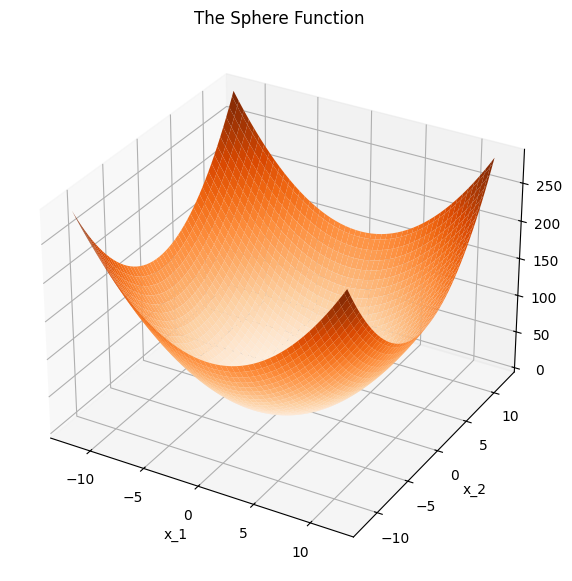

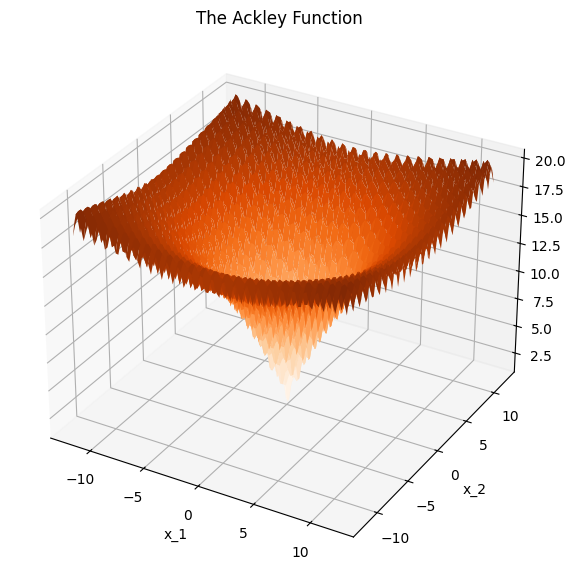

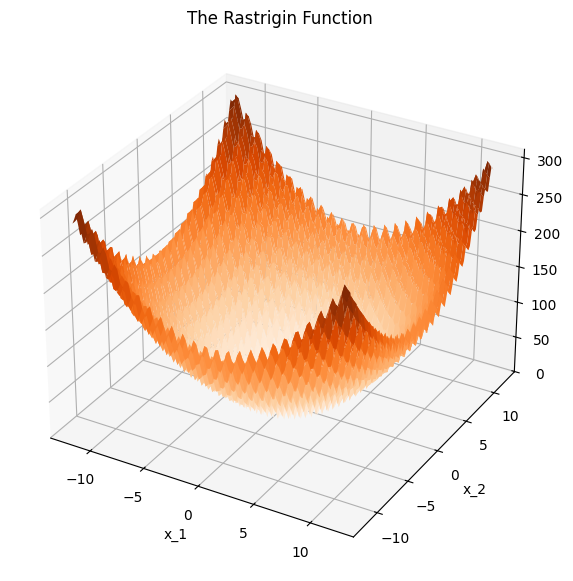

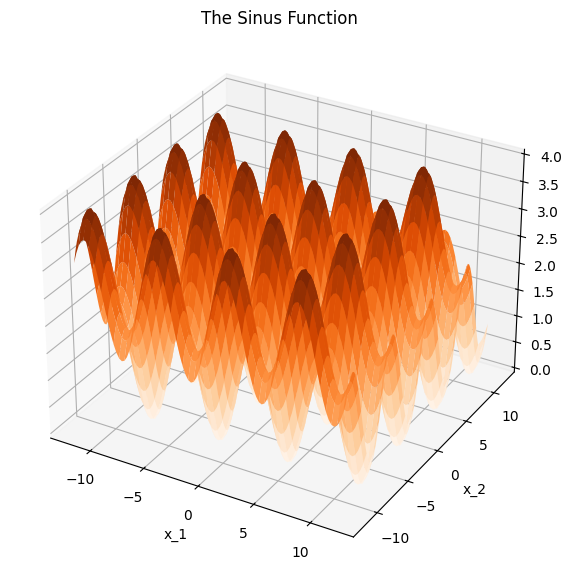

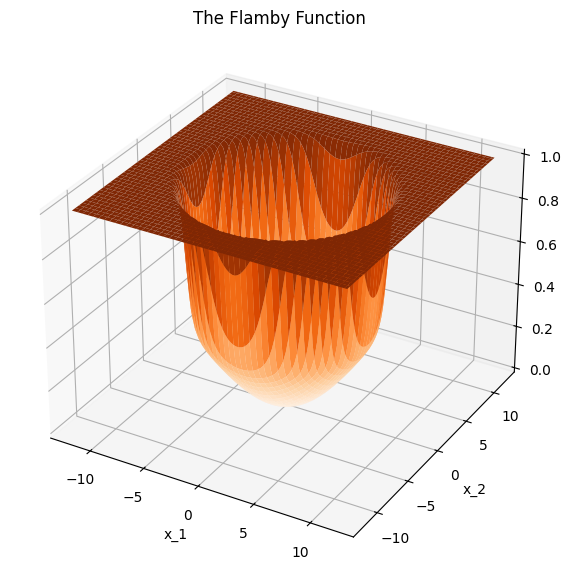



 2026-02-26 13:55:57 GMT
OK.


In [6]:
# myEvalFn
# requires: CMA

import sys
from deap import benchmarks
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def sphere(x):
    return benchmarks.sphere(x)[0]

draw_function(sphere,"The Sphere Function")
print ()

def ackley(x):
    return benchmarks.ackley(x)[0]

draw_function(ackley,"The Ackley Function")
print ()

def rastrigin(x):
    return benchmarks.rastrigin(x)[0]

draw_function(rastrigin,"The Rastrigin Function")
print ()

def multimodal_sine(x):
    """
    Compute the multimodal sine function value for a multi-dimensional input vector x.

    :param x: A numpy array representing the input vector of size N.
    :return: The computed value of the multimodal sine function for each element of x, summed.
    """
    # Apply the sine function to each element of x and sum the results
    result = np.sum(np.sin(x) + 1)
    return result

draw_function(multimodal_sine,"The Sinus Function")
print ()

def sigmoid(x, k=1): # used for Flamby function
    return 1 / (1 + np.exp(-k * x))

# flamby function is a smooth_gaussian which transition from gaussian to flat thanks to a sigmoid
# it works for both single and multiple points
# Usage: flamby(x) => fitness (used for minimisation)
# optional parameters:
#   a for gaussian height
#   c for gaussian width
#   k for sharpness of transition to flat outside the central region
def flamby(x, a=1, c=8, k=5):
    # Determine if x is a single point or an array of points
    if x.ndim == 1:
        dist = np.sqrt(np.sum(x**2))
    else:
        dist = np.sqrt(np.sum(x**2, axis=1))
    gaussian_part = a * np.exp(-(dist)**2 / (2 * c**2))
    transition = sigmoid(k * (c - dist)) * sigmoid(k * (c + dist))
    return 1.0 - gaussian_part * transition

draw_function(flamby,'The Flamby Function')
print ()

# Evaluate the Flamby function for a few single points in 3D and 10D space
'''
x_point = np.array([0.0, 0.0, 0.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.1, 0.1, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([2.0, 2.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([8.0, 8.0, 8.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([9.0, 9.0, 9.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
# remark: increasing the number of dimensions narrow the region with non-flat response.
'''

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")

# Questions

Exécutez la cellule ci-avant et observez les fonctions affichées.

1. Quelles sont les fonctions multimodales?
2. Que dire de la fonction Sinus?
3. Que dire de la fonction Flamby?


1. Multimodal functions have multiple modes and thus do not have unique optimum
2. Sine function is multimodal
3. Flamby has a neutrality plateau and not convex, it has a unique global minimum and infinite number of maxima


---

# Exercice A.2 : recherche au hasard

Le code ci-dessous lance une recherche aléatoire sur une fonction objectif passée en paramètre (fonction Flamby par défaut). Etudiez le code puis exécutez le avant de passer à la suite.

Remarque: *la variable dimensions définit (comme son nom l'indique) le nombre de dimensions du problème. La fonction plot_results n'affiche que les deux premières dimensions. Si le nombre de dimensions est supérieur à 2, la position affichée d'un individu peut ne pas rendre compte exactement de sa qualité.*

In [13]:
# NE PAS MODIFIER -- vous pouvez copier ce code et le modifier pour répondre aux questions des exercices suivants

def launch_random(individual, nbeval=10001, display=True, ma_func=flamby, rangeValue=20):
    i=0
    besteverFit = float("inf")
    besteverIt = 0
    besteverSolution = []
    data = []
    while i<nbeval:
        candidateSolution = np.random.uniform(-rangeValue,+rangeValue,len(individual))
        fit = ma_func(candidateSolution)
        if fit <= besteverFit:
            besteverSolution = np.copy(candidateSolution)
            besteverFit = fit
            besteverIt = i
            besteverSolution = np.array([candidateSolution])
        solution = np.array([candidateSolution])
        data.append(besteverFit)
        #if display and i == 0:
        #  plot_results(ma_func,solution, title="Gen %d"%(i), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
        if display and i%(int(nbeval/10))==0:
          print ("it =",i,", current_fit =",fit,", best_fit =",besteverFit)
        i+=1
    if display:
        plot_results(ma_func,besteverSolution, title="Gen %d"%(besteverIt), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
    print ("Best fit",besteverFit,"found at iteration",besteverIt)
    return besteverFit,data


# Recherche naïve sur les fonctions Sphere, Ackley et Rastrigin

Le code ci-dessous fait une recherche au hasard sur trois fonctions classiques en dimension **2** et avec une initialisation **entre -8 et 8** sur chaque dimension.

Exécutez la cellule, observez le résultat.

# Number of dimensions is 2
# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every 500 evaluations)

=-=-=-=-=
=-=-=-=-= SPHERE
=-=-=-=-=
it = 0 , current_fit = 106.0640365451565 , best_fit = 106.0640365451565
it = 1000 , current_fit = 4.979876489045465 , best_fit = 0.048939070916298316
it = 2000 , current_fit = 34.60987175282412 , best_fit = 0.048939070916298316
it = 3000 , current_fit = 69.12629414915942 , best_fit = 0.0481631979291053
it = 4000 , current_fit = 12.863060836294677 , best_fit = 0.0481631979291053
it = 5000 , current_fit = 51.84996258251141 , best_fit = 0.0481631979291053
it = 6000 , current_fit = 21.788801265482704 , best_fit = 0.0481631979291053
it = 7000 , current_fit = 5.948960706829235 , best_fit = 0.0481631979291053
it = 8000 , current_fit = 26.811454204365216 , best_fit = 0.0481631979291053
it = 9000 , current_fit = 43.54503463481483 , best_fit = 0.0481631979291053
it = 10000 , current_fit = 17.57384600161549 , best_fit = 

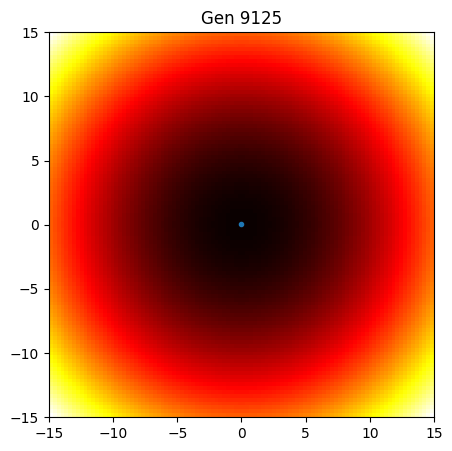

Best fit 0.0043718206327458785 found at iteration 9125


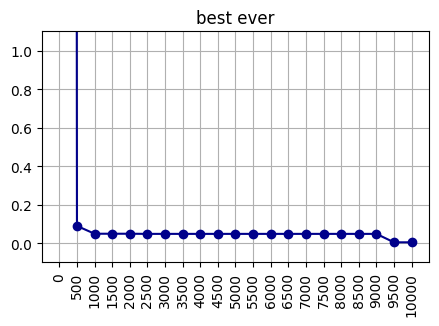


=-=-=-=-=
=-=-=-=-= ACKLEY
=-=-=-=-=
it = 0 , current_fit = 10.55765210755518 , best_fit = 10.55765210755518
it = 1000 , current_fit = 15.109156820602259 , best_fit = 1.7174917598151143
it = 2000 , current_fit = 9.27875603564902 , best_fit = 1.2935125875101667
it = 3000 , current_fit = 4.4108680376711575 , best_fit = 1.1903338237871388
it = 4000 , current_fit = 13.211750708706965 , best_fit = 1.1903338237871388
it = 5000 , current_fit = 12.42314797461766 , best_fit = 0.16716748774530865
it = 6000 , current_fit = 14.266630108517656 , best_fit = 0.16716748774530865
it = 7000 , current_fit = 7.1555663590142045 , best_fit = 0.16716748774530865
it = 8000 , current_fit = 12.344986969960289 , best_fit = 0.16716748774530865
it = 9000 , current_fit = 16.59469327146049 , best_fit = 0.16716748774530865
it = 10000 , current_fit = 14.046519882607518 , best_fit = 0.16716748774530865


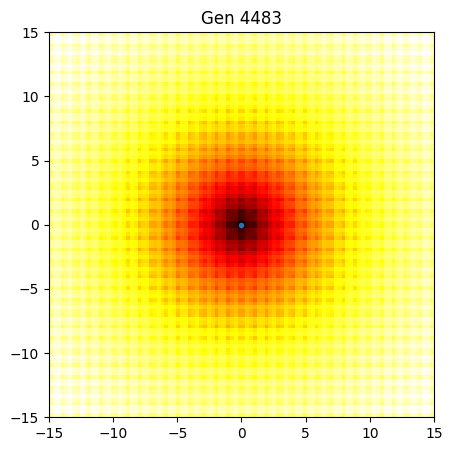

Best fit 0.16716748774530865 found at iteration 4483


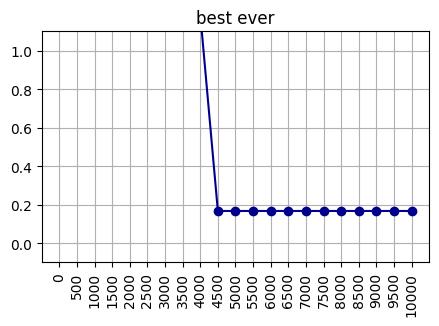


=-=-=-=-=
=-=-=-=-= RASTRIGIN
=-=-=-=-=
it = 0 , current_fit = 75.57467182125643 , best_fit = 75.57467182125643
it = 1000 , current_fit = 50.582251034802965 , best_fit = 4.558065742223851
it = 2000 , current_fit = 89.09484956933065 , best_fit = 4.440556416145547
it = 3000 , current_fit = 54.20020316242325 , best_fit = 2.834961029443633
it = 4000 , current_fit = 76.64754187923506 , best_fit = 1.5639647275073933
it = 5000 , current_fit = 39.0476582789217 , best_fit = 1.5639647275073933
it = 6000 , current_fit = 71.46666471401926 , best_fit = 1.5639647275073933
it = 7000 , current_fit = 123.9949968414468 , best_fit = 1.5639647275073933
it = 8000 , current_fit = 62.74137996147797 , best_fit = 1.5639647275073933
it = 9000 , current_fit = 57.24414124467021 , best_fit = 1.5639647275073933
it = 10000 , current_fit = 57.808189818252615 , best_fit = 1.5639647275073933


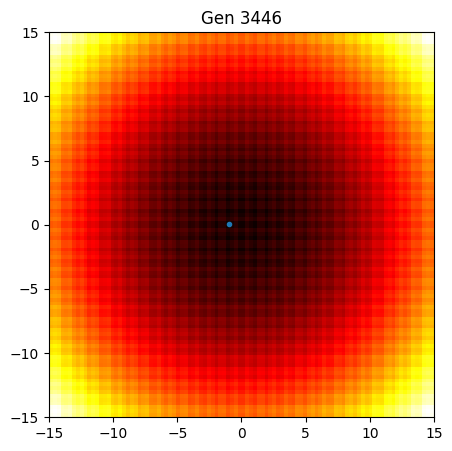

Best fit 1.5639647275073933 found at iteration 3446


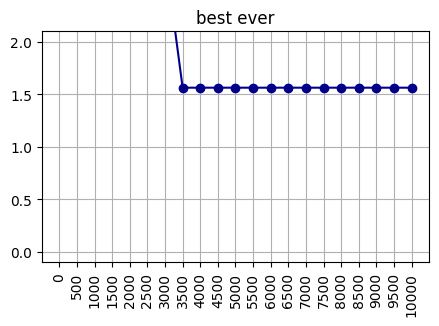

In [15]:
dimensions = 2 # nombre de dimensions de l'espace de recherche
interval=500
print ("# Number of dimensions is",dimensions)
print ("# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every",interval,"evaluations)")

print ("\n=-=-=-=-=\n=-=-=-=-= SPHERE\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=sphere,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)

print ("\n=-=-=-=-=\n=-=-=-=-= ACKLEY\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=ackley,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)

print ("\n=-=-=-=-=\n=-=-=-=-= RASTRIGIN\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=rastrigin,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=2.1)


# Questions

1. Que montre le graphe "Gen XXX" ?
1. Que montre le graphe "best ever"?


1. The graph Gen XXX shows the number of random generations before the best (smallest value) point was found
2. It shows the evolution of the smallest value that randomly obtained up until the generation number indicated on x axis.

# Recherche naïve sur la fonction Sinus

Le code ci-dessous fait une recherche au hasard sur la fonction **Sinus** (multimodale) en dimension **2** et avec une initialisation **entre -8 et 8** sur chaque dimension.

Exécutez la cellule, observez le résultat.

# Number of dimensions is 2
# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every 500 evaluations)

=-=-=-=-=
=-=-=-=-= SINUS
=-=-=-=-=
it = 0 , current_fit = 2.0173265743985063 , best_fit = 2.0173265743985063
it = 1000 , current_fit = 1.8992183151826558 , best_fit = 0.013479764985389275
it = 2000 , current_fit = 1.0350507701298644 , best_fit = 0.0026590611147857546
it = 3000 , current_fit = 0.3692884990510731 , best_fit = 0.0026590611147857546
it = 4000 , current_fit = 3.0122959276515795 , best_fit = 0.0026590611147857546
it = 5000 , current_fit = 3.3172571987600943 , best_fit = 0.0026590611147857546
it = 6000 , current_fit = 3.094373272622181 , best_fit = 0.0026590611147857546
it = 7000 , current_fit = 1.6396455707449547 , best_fit = 0.0026590611147857546
it = 8000 , current_fit = 2.0603617686847078 , best_fit = 0.0026590611147857546
it = 9000 , current_fit = 0.5553356888613311 , best_fit = 0.0026590611147857546
it = 10000 , current_fit = 2.6

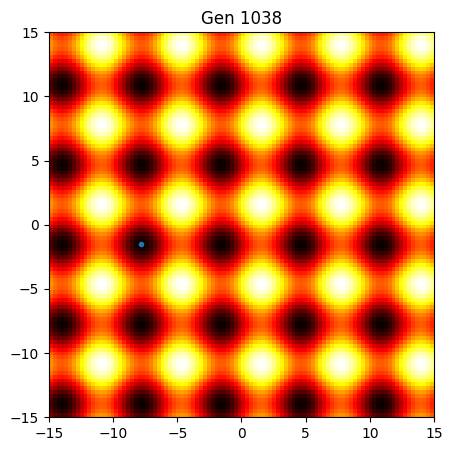

Best fit 0.0026590611147857546 found at iteration 1038


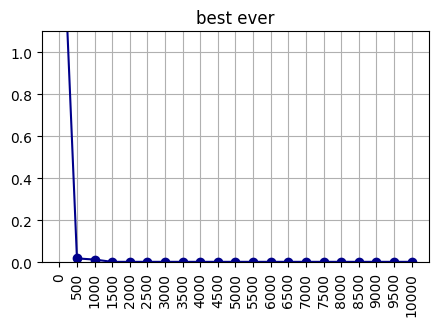

In [29]:
dimensions = 2 # nombre de dimensions de l'espace de recherche
interval=500
print ("# Number of dimensions is",dimensions)
print ("# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every",interval,"evaluations)")

print ("\n=-=-=-=-=\n=-=-=-=-= SINUS\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=multimodal_sine,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=0,y_max=1.1)


# Questions

1. Relancer plusieurs fois la recherche aléatoire sur la fonction Sinus. Qu'observez-vous? Pourquoi?


1. Since sine function has multiple global minima, and thus the best ever value is always the same (second graph), however the position of this optimum is found in different places depending on the seed (randomness)

# Recherche naïve sur la fonction Flamby

Le code ci-dessous fait une recherche au hasard sur la fonction **Flamby** en dimension **12** et avec une initialisation **entre -8 et 8** sur chaque dimension.

Exécutez la cellule, observez le résultat.


=-=-=-=-=
=-=-=-=-= FLAMBY
=-=-=-=-=
it = 0 , current_fit = 1.0 , best_fit = 1.0
it = 1000 , current_fit = 1.0 , best_fit = 0.9999998632676966
it = 2000 , current_fit = 1.0 , best_fit = 0.9999998632676966
it = 3000 , current_fit = 1.0 , best_fit = 0.9999948331127836
it = 4000 , current_fit = 1.0 , best_fit = 0.9999948331127836
it = 5000 , current_fit = 1.0 , best_fit = 0.9999876941718587
it = 6000 , current_fit = 1.0 , best_fit = 0.9999876941718587
it = 7000 , current_fit = 1.0 , best_fit = 0.9999876941718587
it = 8000 , current_fit = 1.0 , best_fit = 0.9999876941718587
it = 9000 , current_fit = 1.0 , best_fit = 0.9999876941718587
it = 10000 , current_fit = 1.0 , best_fit = 0.9999876941718587


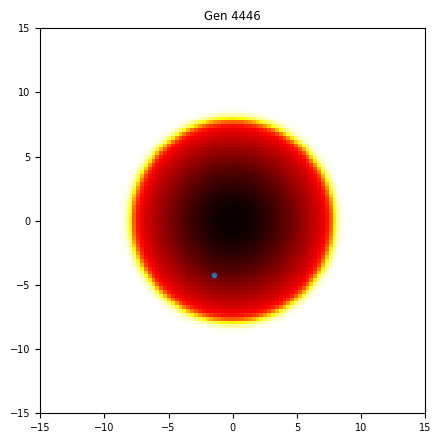

Best fit 0.9999876941718587 found at iteration 4446


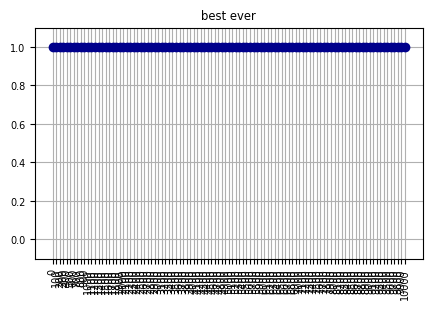

In [857]:

print ("\n=-=-=-=-=\n=-=-=-=-= FLAMBY\n=-=-=-=-=")
dimensions = 15#12
rangeValue = 8 # 5
res,data = launch_random([0]*dimensions,ma_func=flamby,rangeValue=rangeValue)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)


# Questions

1. Modifiez le code ci-dessus pour faire une recherche en 2, puis en 20 dimensions. Qu'observez vous? Pourquoi?


1. The higher the dimensionality is, the more of random generations are necessary to cover this space and find the optimum - it is one of manifestations of curse of dimensionality

---
---
---

# <font color='orange'>PARTIE B : STRATEGIES D'EVOLUTION</font>


---

# Exercice B-1: algorithme (1+1)-ES

Implementez une stratégie d'évolution (1+1)-ES avec un sigma fixe dans la cellule ci-dessous. Vous pouvez vous inspirer de la fonction de recherche aléatoire présentée précédemment pour la structure globale.

Vous testerez cet algorithme sur la fonction Flamby présenté précédemment. Vous tracerez (comme montré à la question précédente) l'évolution de la population pour chaque exécution.


=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES
=-=-=-=-=
it = 0 , current_fit = 1.0 , best_fit = 1.0
it = 1000 , current_fit = 1.0 , best_fit = 1.0
it = 2000 , current_fit = 1.0 , best_fit = 1.0
it = 3000 , current_fit = 1.0 , best_fit = 1.0
it = 4000 , current_fit = 1.0 , best_fit = 1.0
it = 5000 , current_fit = 1.0 , best_fit = 1.0
it = 6000 , current_fit = 1.0 , best_fit = 1.0
it = 7000 , current_fit = 1.0 , best_fit = 1.0
it = 8000 , current_fit = 1.0 , best_fit = 1.0
it = 9000 , current_fit = 1.0 , best_fit = 1.0
it = 10000 , current_fit = 1.0 , best_fit = 1.0


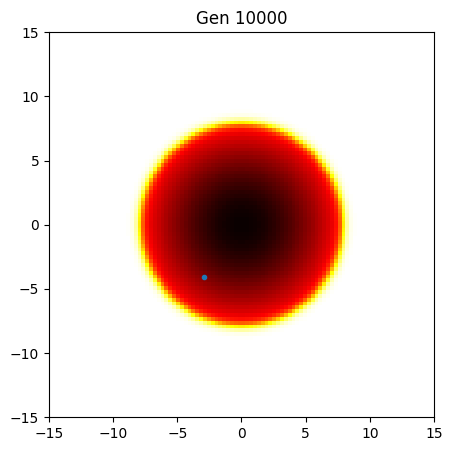

Best fit 1.0 found at iteration 10000


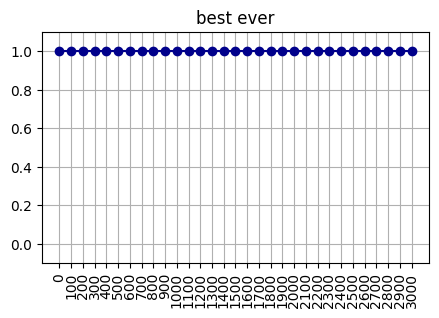

(display only the first 3000 iterations)


In [331]:
def launch_oneplusone(individual, sigma, nbeval=10001, display=True, ma_func=sphere):
    i=0
    besteverFit = float("inf")
    besteverIt = 0
    besteverSolution = individual  # NOTE
    data = []
    while i<nbeval:
        candidateSolution = np.random.randn(len(individual))*sigma + besteverSolution[-1] # NOTE
        fit = ma_func(candidateSolution)
        if fit <= besteverFit:
            besteverSolution = np.copy(candidateSolution)
            besteverFit = fit
            besteverIt = i
            besteverSolution = np.array([candidateSolution])
            individual = candidateSolution # NOTE
        solution = np.array([candidateSolution])
        data.append(besteverFit)
        #if display and i == 0:
        #  plot_results(ma_func,solution, title="Gen %d"%(i), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
        if display and i%(int(nbeval/10))==0:
          print ("it =",i,", current_fit =",fit,", best_fit =",besteverFit)
        i+=1
    if display:
        plot_results(ma_func,besteverSolution, title="Gen %d"%(besteverIt), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
    print ("Best fit",besteverFit,"found at iteration",besteverIt)
    return besteverFit,data
    
print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES\n=-=-=-=-=")

dimensions = 20#12
rangeValue = 10#5
initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
res,data = launch_oneplusone(initial_solution,sigma=0.01,nbeval=10001,ma_func=flamby)

interval = 100
plot_data(data[:3001],title="best ever",interval=interval,y_min=-0.1,y_max=1.1)
print("(display only the first 3000 iterations)")



# Questions

1. lancer la recherche en changeant l'ordre de grandeur de sigma (ie. 0.1 et 0.001). Qu'observez-vous?

2. lancer plusieurs fois la recherche avec 2 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10 et sigma=0.01. Qu'observez-vous?

3. lancer plusieurs fois la recherche avec 20 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10. Qu'observez-vous? Pourquoi?

4. Pourquoi le remplacement du parent par l'enfant se fait aussi si les deux ont la même performance?


1. For smaller values of sigma the solution space exploration is slower ans so is the convergence, the model gets stuck more often in the plateau of neutrality
2. If the initial solution is initiated in the larger range ( [-10, 10] ) then the chance of starting on the plateau and far away from the edge of the flamby depression and thus get stuck stuck as well
3. In 20-dimensional space the situation with being stuck on the plateau is even worse due to the higher number of dimensions needed to be explored in order to escape it 
4. Equality part is important in update condition (`if fit <= besteverFit:`) because it avoids the idviduals from stopping the exploration on the plateau

---

# Exercice B-2: algorithme (1+1)-ES, règle des 1/5e

Nous allons maintenant implementer une stratégie d'évolution (1+1)-ES avec un sigma suivant la règle des 1/5e. Limitez la valeur de sigma entre 1e-10 et 2.

Vous testerez cette algorithme sur les mêmes fonction que précédemment. Vous tracerez l'évolution de la population pour chaque exécution. Vous étudierez l'impact du choix du point initial et du sigma.


=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule
=-=-=-=-=
it = 0 , current_fit = 1.0 , best_fit = 1.0
it = 1000 , current_fit = 1.0 , best_fit = 1.0


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_78452/542463808.py:43: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-k * x))
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_78452/542463808.py:55: RuntimeWarning: overflow encountered in square
  dist = np.sqrt(np.sum(x**2))
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_78452/2646436428.py:9: RuntimeWarning: overflow encountered in multiply
  candidateSolution = np.random.randn(len(individual))*sigma + besteverSolution[-1] # NOTE
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_78452/2646436428.py:9: RuntimeWarning: overflow encountered in add
  candidateSolution = np.random.randn(len(individual))*sigma + besteverSolution[-1] # NOTE
/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_78452/2646436428.py:9: RuntimeWarning: invalid value encountered in add
  candidateSolution = np.random.randn(len(individual))*sigma + besteverSolution[-1] # NOTE


it = 2000 , current_fit = nan , best_fit = 1.0
it = 3000 , current_fit = nan , best_fit = 1.0
it = 4000 , current_fit = nan , best_fit = 1.0
it = 5000 , current_fit = nan , best_fit = 1.0
it = 6000 , current_fit = nan , best_fit = 1.0
it = 7000 , current_fit = nan , best_fit = 1.0
it = 8000 , current_fit = nan , best_fit = 1.0
it = 9000 , current_fit = nan , best_fit = 1.0
it = 10000 , current_fit = nan , best_fit = 1.0


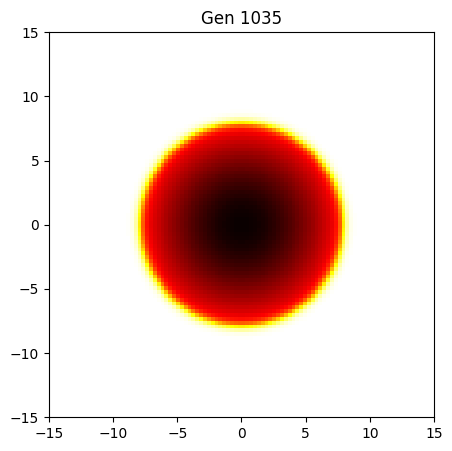

Best fit 1.0 found at iteration 1035


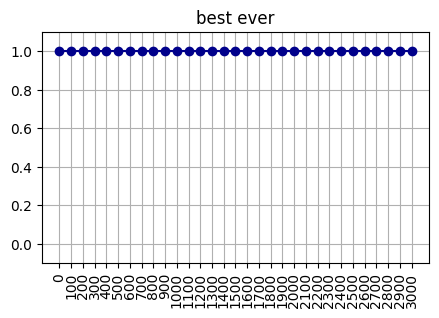

(display only the first 3000 iterations)
Terminé.


In [324]:
def launch_oneplusone_withOneFifthRule(individual, sigma_init=0.01, nbeval=10001, display=True, ma_func=sphere):
    sigma = sigma_init # NOTE
    i=0
    besteverFit = float("inf")
    besteverIt = 0
    besteverSolution = individual  # NOTE
    data = []
    while i<nbeval:
        candidateSolution = np.random.randn(len(individual))*sigma + besteverSolution[-1] # NOTE
        fit = ma_func(candidateSolution)
        if fit <= besteverFit:
            besteverSolution = np.copy(candidateSolution)
            besteverFit = fit
            besteverIt = i
            besteverSolution = np.array([candidateSolution])
            individual = candidateSolution # NOTE
            sigma *= 2 # NOTE
        else:
            sigma *= 2**(-1/4) # NOTE
        solution = np.array([candidateSolution])
        data.append(besteverFit)
        #if display and i == 0:
        #  plot_results(ma_func,solution, title="Gen %d"%(i), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
        if display and i%(int(nbeval/10))==0:
          print ("it =",i,", current_fit =",fit,", best_fit =",besteverFit)
        i+=1
    if display:
        plot_results(ma_func,besteverSolution, title="Gen %d"%(besteverIt), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
    print ("Best fit",besteverFit,"found at iteration",besteverIt)
    return besteverFit,data

print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule\n=-=-=-=-=")

dimensions = 20#12
rangeValue = 10#5
initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
res,data = launch_oneplusone_withOneFifthRule(initial_solution,nbeval=10001,sigma_init=0.01,ma_func=flamby)

interval = 100
plot_data(data[:3001],title="best ever",interval=interval,y_min=-0.1,y_max=1.1)
print("(display only the first 3000 iterations)")

print ("Terminé.")

# Questions

1. lancer plusieurs fois la recherche avec 2 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10. Comparez avec les résultats obtenus précédemment. Qu'observez-vous?

2. lancer plusieurs fois la recherche avec 20 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10. Qu'observez-vous?


1. In this case the idviduals escape the plateau faster, this is due to the fact that exploration noise increases in case where fitness value doesn't get worse
2. However, the curse of dimensionality is still present and the individual is still stuck on the plateau pretty often, however if it converges, it converges faster 

---

# Exercice B-3: algorithme CMA-ES

Nous allons maintenant utiliser CMA-ES. La version standard est celle proposée dans la bibliothèque pycma (https://github.com/CMA-ES/pycma). Vous testerez cette bibliothèque sur les mêmes fonctions que précédemment.



=-=-=-=-=
=-=-=-=-= Flamby Function with CMA-ES
=-=-=-=-=
(5_w,11)-aCMA-ES (mu_w=3.4,w_1=42%) in dimension 12 (seed=204399, Thu Feb 26 17:56:19 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     11 1.043343665323610e+01 1.0e+00 1.03e+00  1e+00  1e+00 0:00.0
    2     22 9.897681051854128e+00 1.2e+00 1.08e+00  1e+00  1e+00 0:00.0
    3     33 9.495106248073983e+00 1.2e+00 1.09e+00  1e+00  1e+00 0:00.0
  100   1100 8.591108134123004e-03 1.9e+00 5.46e-03  3e-03  3e-03 0:00.0
  200   2200 1.101493254163088e-05 2.0e+00 8.63e-06  2e-06  3e-06 0:00.1
  300   3300 3.630830747169966e-09 1.8e+00 8.46e-09  1e-09  1e-09 0:00.1
  376   4136 2.664890530468256e-11 2.0e+00 9.05e-11  7e-12  8e-12 0:00.1
termination on {'tolx': 1e-11}
final/bestever f-value = 2.664891e-11 2.471268e-11 after 4136/4122 evaluations
incumbent solution: [-3.59865056e-12  9.99951061e-12  5.74140302e-12 -5.35366854e-12
  4.26983219e-12  4.22242091e-14  7.38509040e-12 -3.16055114e-12 ...]
s

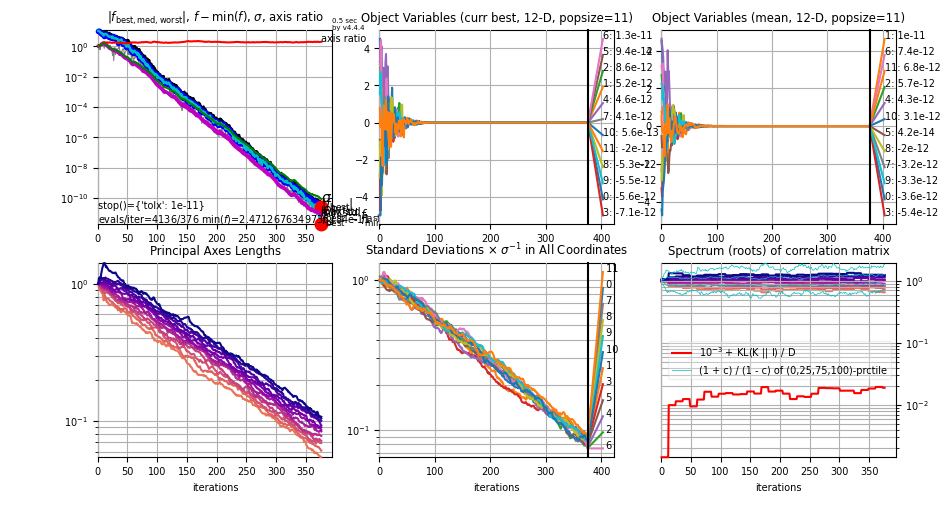

Population size: 11
Best solution: [-3.66655630e-12  1.46346588e-11  5.99124932e-12  7.35410805e-13
  6.95824303e-12 -2.52993341e-12  6.33178584e-12 -1.79418271e-12
 -4.00462948e-13 -4.61043334e-12  3.85846511e-13  8.61421735e-12]
Best fitness: 2.4712676349736284e-11
Terminé.


In [860]:
# python -m pip install cma -- déjà fait avant.
import cma

def launch_cmaes(dim=12, display=True, ma_func=flamby):

    rangeValue = 5

    es = cma.CMAEvolutionStrategy(
      x0=np.random.uniform(-rangeValue, rangeValue, dim),
      sigma0=1,
      inopts = {'bounds': [-rangeValue, rangeValue]}
    )

    es.optimize(ma_func)

    if display:
        es.result_pretty()
        es.plot()
        plt.show()
        
    result = es.result
    print("Population size:", int(es.opts["popsize"]))
    print("Best solution:", result.xbest)
    print("Best fitness:", result.fbest)
    return float(result.fbest)

print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with CMA-ES\n=-=-=-=-=")

dimensions = 12 # 100
ma_func =(flamby, ackley, rastrigin)[1]
besteverFitness = launch_cmaes(dim=dimensions,display=True,ma_func=ma_func)

print ("Terminé.")

# Questions

1. lancez la recherche avec CMA-ES en 12 dimensions. Comparez avec les algos précédents. Qu'observez-vous?

2. lancez la recherche avec CMA-ES en 100 dimensions. Comparez avec les algos précédents. Qu'observez-vous?

3. lancez la recherche avec CMA-ES en 12 dimensions sur d'autres fonctions plus complexes (Rastrigin et Ackley). Comparez avec les algos précédents. Qu'observez-vous?

4. Commentez les graphes générés par CMAES

5. Comment forcer cma-es à chercher des valeurs de paramètres dans un intervale limité à [-5,+5]? Aide: lisez la section "Practical Hints" de https://cma-es.github.io/cmaes_sourcecode_page.html



1. Compared to previous algorithms, CMA-ES converges in a smaller number of iterations (around 50 for flamby), however the size of generation is bigger (population size is 11)
2. In 100-dimensional space the algorithm never converged, thus the dimensionality curse is still present in this case
3. Ackley requires around twice as more iterations to converge, apparently because of the fact that the algorithm gets trapped in local minima ("distracted" by them), and it doesn't converge to zero for Rastrigin, it converges to a local minimum instead, apparently because the slope of the overall landscape is not big enough.
4. Graphs are showing evolution of various parameters during learning: 
    - objective function (decreases)
    - coordinates for each dimensions of best individuum and of the population mean (in our case dicrease because optimum is at [0, .., 0])
    - standard deviations in original dimensions, as well as in principal components (showing dimensions of "noise ellipse") - noise dicreases as the algorithm converges
    - correlation matrix eigenvalues and other parameters that can be relevant to the convergence...
5. In the python library `cma` we are using, bounds are handles using a penalty to objective function, however, it's enough for us to just indicate it as a `inopts={"bounds": [-5, 5]}` as a parameter in the API.

---
---
---

# <font color='orange'>PARTIE C : PERFORMANCE</font>

---

# Exercice C-1: stabilité des résultats

Tous les algorithmes vus jusqu'ici utilisent des opérateurs stochastiques. Même en partant des mêmes conditions initiales (solution initiale et paramètres identitiques), deux éxecutions du même algorithme peut donner des résultats différents.

Le code ci-dessous permet d'exécuter 10 fois de suite une recherche au hasard pour le problème de la fonction Flamby pour respectivement 4, 16 puis 32 dimensions (i.e. 3x10 exécutions en tout).

Exécutez la cellule et observez les résultats.

Random search on Flamby function with 4 dimensions
Best fit 0.002134525243483787 found at iteration 9058
Best fit 0.003729095421189821 found at iteration 3177
Best fit 0.005994346455627242 found at iteration 6563
Best fit 0.006986391921258939 found at iteration 9499
Best fit 0.00461321626248512 found at iteration 3229
Best fit 0.004923179436090108 found at iteration 1757
Best fit 0.0020038982969411423 found at iteration 665
Best fit 0.00538181210001154 found at iteration 4252
Best fit 0.003415314214959886 found at iteration 4249
Best fit 0.00323047889416328 found at iteration 6552
Random search on Flamby function with 16 dimensions
Best fit 0.2218282103919763 found at iteration 3981
Best fit 0.2707147338273511 found at iteration 5537
Best fit 0.15857278268747943 found at iteration 7041
Best fit 0.24946948276867176 found at iteration 2950
Best fit 0.23168179538931244 found at iteration 2020
Best fit 0.22542889303422786 found at iteration 11
Best fit 0.24063900421364326 found at iteratio

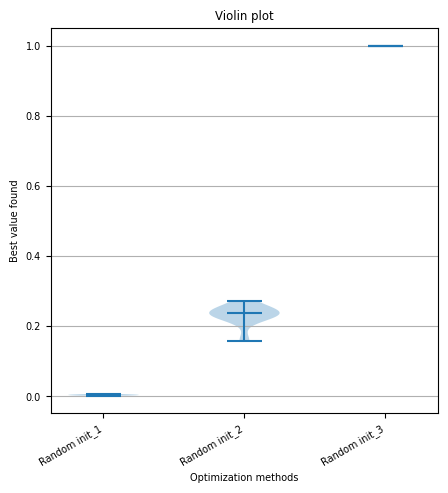

Terminé.


In [770]:
# fourni a titre d'exemple, ne pas modifier -- répondre dans la cellule suivante.

resRandom_1 = []
resRandom_2 = []
resRandom_3 = []

allResults = {}

centerInit_1 = [0]*4
centerInit_2 = [0]*16
centerInit_3 = [0]*32

evaluationBudget = 10001
evalFunc = flamby

print("Random search on Flamby function with",len(centerInit_1),"dimensions")
for i in range(10):
    resRandom_1.append ( launch_random(centerInit_1,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=5)[0] )
allResults["Random init_1"] = resRandom_1

print("Random search on Flamby function with",len(centerInit_2),"dimensions")
for i in range(10):
    resRandom_2.append ( launch_random(centerInit_2,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=5)[0] )
allResults["Random init_2"] = resRandom_2

print("Random search on Flamby function with",len(centerInit_3),"dimensions")
for i in range(10):
    resRandom_3.append ( launch_random(centerInit_3,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=5)[0] )
allResults["Random init_3"] = resRandom_3

plot_violin( allResults )

print ("Terminé.")


# Questions

1. Qu'observez vous, en particulier pour le second setup? Pourquoi?

2. Pourquoi est-ce différent pour les deux autres setups?


1. For the second case with 16 dimensions the random algorithm sometimes finds the optimum, sometimes it stays on the plateau or in suboptimal solutions 

2. In case of 4 dimensions, the found solution is consistently close to the global optimum, on the contrary, for 32 dimensions the algorithm starts at the plateau and never proposes a better solution since it's more probable to end up on the plateau then on the spherical region near the optimum

---

# Exercice C-2: comparaison des algorithmes

On souhaite maintenant comparer les différents algorithmes jusqu'ici (random search, (1+1)-ES, (1+1)-ES 1/5th rule, CMAES) et deux algorithmes plus classiques (Nelder Mead et Powell). Etudiez et exécutez le code ci-dessous.

Random search on Flamby function with 16 dimensions
Best fit 0.2340176359738444 found at iteration 9511
Best fit 0.28674599782612253 found at iteration 6891
Best fit 0.2805860000110607 found at iteration 2849
Best fit 0.29622269673090307 found at iteration 5732
Best fit 0.2763726193052245 found at iteration 1782
Best fit 0.26476752634690226 found at iteration 6281
Best fit 0.20051351598771672 found at iteration 5914
Best fit 0.2406839282272918 found at iteration 416
Best fit 0.266049958108734 found at iteration 9437
Best fit 0.30339046731550134 found at iteration 8240
(1+1)-ES search on Flamby function with 16 dimensions
Best fit 1.0 found at iteration 10000
Best fit 3.3472611131735164e-06 found at iteration 1553
Best fit 2.557552377657757e-06 found at iteration 6561
Best fit 2.7461307651188704e-06 found at iteration 7928
Best fit 1.133967742839026e-05 found at iteration 9987
Best fit 3.5713182674479427e-06 found at iteration 8196
Best fit 3.0411287830212075e-06 found at iteration 5117

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_78452/3598012525.py:2: OptimizeWarning: Unknown solver options: xtol
  nelder = minimize(ma_func, center, method='nelder-mead',options={'xtol': 1e-8, 'disp': display})



0.10146837579264922


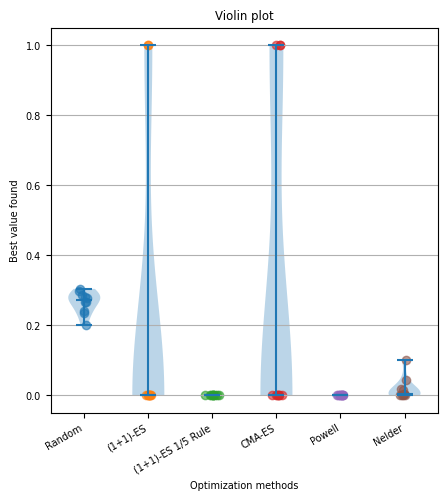

Terminé.


In [811]:
def launch_nelder(center, nbeval=10001, display=False, ma_func=sphere):
    nelder = minimize(ma_func, center, method='nelder-mead',options={'xtol': 1e-8, 'disp': display})
    print (nelder.fun)
    return nelder.fun

def launch_powell(center, nbeval=10001, display=False, ma_func=sphere):
    powell = minimize(ma_func, center, method='powell',options={'xtol': 1e-8, 'disp': display})
    print (powell.fun)
    return powell.fun

resRandom = []
res1p1 = []
res1p1rule15 = []
rescmaes = []
resPowell = []
resNelder = []

allResults = {}

centerInit = [0]*16 # 16
rangeValue = 5

evaluationBudget = 10001
evalFunc = flamby

algos = {"Random": launch_random,
         "(1+1)-ES": launch_oneplusone,
         "(1+1)-ES 1/5-th":launch_oneplusone_withOneFifthRule}

print("Random search on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) # useless for random search
    resRandom.append (launch_random(centerInit,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=rangeValue)[0] )
    allResults["Random"] = resRandom

# Added Start

print("(1+1)-ES search on Flamby function with", len(centerInit), "dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) 
    res1p1.append(launch_oneplusone(centerInit, sigma=0.01, nbeval=evaluationBudget, display=False, ma_func=evalFunc)[0])
    allResults["(1+1)-ES"] = res1p1

print("(1+1)-ES with 1/5 rule search on Flamby function with", len(centerInit), "dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) 
    res1p1rule15.append(launch_oneplusone_withOneFifthRule(centerInit, sigma_init=0.01, nbeval=evaluationBudget, display=False, ma_func=evalFunc)[0])
    allResults["(1+1)-ES 1/5 Rule"] = res1p1rule15

print("CMA-ES search on Flamby function with", len(centerInit), "dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) 
    rescmaes.append(launch_cmaes(len(centerInit), display=False, ma_func=evalFunc))
    allResults["CMA-ES"] = rescmaes

# Added End

print("Powell on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit))
    resPowell.append( launch_powell(centerInit, nbeval=evaluationBudget, display=False, ma_func=evalFunc) )
allResults["Powell"] = resPowell

print("Neldermead on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit))
    resNelder.append ( launch_nelder(centerInit, nbeval=evaluationBudget, display=False, ma_func=evalFunc) )
allResults["Nelder"] = resNelder

plot_violin( allResults )

print ("Terminé.")


Random search on Flamby function with 100 dimensions
Best fit 1423.2539146199265 found at iteration 8725
Best fit 1440.040574619072 found at iteration 2548
Best fit 1373.6957696148638 found at iteration 4046
Best fit 1396.2949403229682 found at iteration 9858
Best fit 1484.3271977010286 found at iteration 9912
Best fit 1444.2010818147974 found at iteration 1179
Best fit 1458.331014005937 found at iteration 8115
Best fit 1453.998246997479 found at iteration 6759
Best fit 1465.7030210420999 found at iteration 6836
Best fit 1459.2860652195775 found at iteration 8687
(1+1)-ES search on Flamby function with 100 dimensions
Best fit 2492.4129716974257 found at iteration 9826
Best fit 2491.985271634767 found at iteration 9762
Best fit 1596.6627829218462 found at iteration 7656
Best fit 102.16120606752236 found at iteration 0
Best fit 899.9761336656742 found at iteration 8460
Best fit 1595.8603148016928 found at iteration 9492
Best fit 402.2091766274565 found at iteration 9167
Best fit 401.7470

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_78452/3003779055.py:2: OptimizeWarning: Unknown solver options: xtol
  nelder = minimize(ma_func, center, method='nelder-mead',options={'xtol': 1e-8, 'disp': display})


783.0287090492184
889.4877510023376
883.5187027183042
696.4680135429596
713.3822763089731
788.997618391045
920.3310672517135
917.346805714308
692.4881930175068
801.933037708322


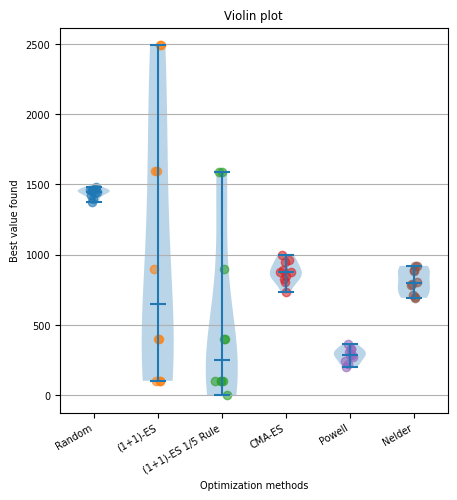

Terminé.


In [855]:
def launch_nelder(center, nbeval=10001, display=False, ma_func=sphere):
    nelder = minimize(ma_func, center, method='nelder-mead',options={'xtol': 1e-8, 'disp': display})
    print (nelder.fun)
    return nelder.fun

def launch_powell(center, nbeval=10001, display=False, ma_func=sphere):
    powell = minimize(ma_func, center, method='powell',options={'xtol': 1e-8, 'disp': display})
    print (powell.fun)
    return powell.fun

resRandom = []
res1p1 = []
res1p1rule15 = []
rescmaes = []
resPowell = []
resNelder = []

allResults = {}

centerInit = [0]*100 # 16
rangeValue = 5

evaluationBudget = 10001
evalFunc = rastrigin

algos = {"Random": launch_random,
         "(1+1)-ES": launch_oneplusone,
         "(1+1)-ES 1/5-th":launch_oneplusone_withOneFifthRule}

print("Random search on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) # useless for random search
    resRandom.append (launch_random(centerInit,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=rangeValue)[0] )
    allResults["Random"] = resRandom

# Added Start

print("(1+1)-ES search on Flamby function with", len(centerInit), "dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) 
    res1p1.append(launch_oneplusone(centerInit, sigma=0.01, nbeval=evaluationBudget, display=False, ma_func=evalFunc)[0])
    allResults["(1+1)-ES"] = res1p1

print("(1+1)-ES with 1/5 rule search on Flamby function with", len(centerInit), "dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) 
    res1p1rule15.append(launch_oneplusone_withOneFifthRule(centerInit, sigma_init=0.01, nbeval=evaluationBudget, display=False, ma_func=evalFunc)[0])
    allResults["(1+1)-ES 1/5 Rule"] = res1p1rule15

print("CMA-ES search on Flamby function with", len(centerInit), "dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) 
    rescmaes.append(launch_cmaes(len(centerInit), display=False, ma_func=evalFunc))
    allResults["CMA-ES"] = rescmaes

# Added End

print("Powell on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit))
    resPowell.append( launch_powell(centerInit, nbeval=evaluationBudget, display=False, ma_func=evalFunc) )
allResults["Powell"] = resPowell

print("Neldermead on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
    centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit))
    resNelder.append ( launch_nelder(centerInit, nbeval=evaluationBudget, display=False, ma_func=evalFunc) )
allResults["Nelder"] = resNelder

plot_violin( allResults )

print ("Terminé.")


# Questions

Remarque: les algorithmes produisant des résultats très différents, n'hésitez pas à supprimer l'affichage des plus mauvais pour pouvoir distinguer les meilleurs.

1. ajoutez les algorithmes vus précédemment. Comparez sur la fonction Flamby en 16 dimensions. Qu'observez-vous?

2. comparez sur la fonction Rastrigin en 100 dimensions. Qu'observez-vous?

3. dans la question (2), modifiez les paramètres de CMAES concernant les conditions d'arrêt de l'algorithme pour obtenir une meilleure performance (cf. docs pour les paramètres). Etudiez en particulier la tolérance pour l'arrêt prématuré de la recherche et la possibilité de faire un Restart (cf. docs).


1. For flamby with 16 dimensions observe that:
    -  Powell and (1+1)-ES with 1/5 rule always find the optimal solution
    - CMA-ES, (1+1)-ES sometimes find the optimum, sometimes are blocked on the plateau
    - Nelder often finds optimal or suboptimal solutions, sometimes beings blocked in plateau
    - random strategy results consistently in suboptimal solutions
2. For Rastrigin with 100 dimensions observe that:
    - random strategy performs the worst never finding optimal or close to optimal solutions
    - CMA-ES, Nelder and Powell algorithms find subotimal solutions, but never the global optimum (Powell finding better solutions than Nelder amd CMA-ES)
    - (1+1)-ES with and without 1/5 rule show more variance in the results, especislly in case without 1/5 rule
In general, we can notice that in low dimensional case the random strategy appears to be quite good choice especcially given its simplicity.
3. See the code below, for implementation with `fmin2` for the multiple restarts, happily for us, it finds the global minimum of the Rastrigin function, which was not the case before. Apparently, multiple restarts compensate for getting stuck at local minima.

In [853]:
def launch_cmaes2(dim=12, display=True, ma_func=flamby):

    # rangeValue = 5

    es = cma.CMAEvolutionStrategy(
      x0=np.random.uniform(-rangeValue, rangeValue, dim),
      sigma0=1e-2,
      inopts = {'bounds': [-rangeValue, rangeValue]}
    )
    options = {'seed':12345, 'verb_time':0, 'ftarget': 1e-8}
    # res = cma.fmin2(ma_func, lambda : 2. * np.random.rand(dim) - 1, 0.5,#np.random.uniform(-rangeValue, rangeValue, dim)
    #                              1e-2, restarts=2, bipop=True)
    res = cma.fmin(ma_func, lambda : 2. * np.random.rand(3) - 1, 0.5,
                options, restarts=9, bipop=True)  
    print("Best fitness:", res[1])
    return res[1]

In [854]:
# es.optimize(ma_func)
res = launch_cmaes2(dim=12, display=True, ma_func=rastrigin)

(5_w,11)-aCMA-ES (mu_w=3.4,w_1=42%) in dimension 12 (seed=237960, Thu Feb 26 17:42:53 2026)
(3_w,7)-aCMA-ES (mu_w=2.3,w_1=58%) in dimension 3 (seed=12345, Thu Feb 26 17:42:53 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      7 2.288855012967919e+01 1.0e+00 4.87e-01  4e-01  5e-01 
    2     14 1.661004254326615e+01 1.4e+00 5.81e-01  6e-01  6e-01 
    3     21 2.302808097360272e+01 1.5e+00 7.22e-01  7e-01  9e-01 
  100    700 5.969749305332524e+00 1.8e+00 1.53e-04  1e-06  2e-06 
  137    959 5.969749304740674e+00 1.6e+00 2.65e-06  3e-09  4e-09 
termination on {'tolfun': 1e-11} (Thu Feb 26 17:42:53 2026)
final/bestever f-value = 5.969749e+00 3.983520e+00 after 960/94 evaluations
incumbent solution: [0.99495864, 0.99495864, 1.98991223]
std deviations: [3.07039078e-09, 2.77171881e-09, 3.91654117e-09]
(7_w,14)-aCMA-ES (mu_w=4.3,w_1=36%) in dimension 3 (seed=12346, Thu Feb 26 17:42:53 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std 

---
---
---

# <font color='orange'>PARTIE D : BONUS</font>

Exercice optionnel à faire en autonomie.

Implémentez l'algorithme CEM (Cross-Entropy Method) vu en cours. Comparez avec les algorithmes précédents, en particulier CMA-ES.

In [ ]:
# A compléter

*Fin du sujet.*
